In [1]:
import os

# This forces TensorFlow to use the internal Keras 2 instead of the new Keras 3
os.environ['TF_USE_LEGACY_KERAS'] = '1'

### Installing pydot and graphviz libraries to plot models:

In [2]:
# Run below lines if 'pydot' and 'graphviz' libraries are not already installed:

# !pip install pydot graphviz

# Importing Necessary Libraries:

In [3]:
import os
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Conv1D, Dense, LSTM, GRU, TextVectorization, Embedding
from tensorflow.keras.layers import GlobalAveragePooling1D, GlobalMaxPool1D, Bidirectional
from tensorflow.keras.layers import Concatenate, Dropout
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

from sklearn.preprocessing import OneHotEncoder, LabelEncoder

2026-02-23 12:54:17.238437: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 12:54:17.283015: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 12:54:18.646964: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/shail/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/tensorflow_hub/__init__.py:

# Downloading Helper Functions Script

In [4]:
# Run the below lines if helper functions are not already downloaded:
# Downloading Helper Functions:

#import wget
#url = 'https://raw.githubusercontent.com/Shailya777/Learning-Logs/refs/heads/main/Deep_Learning_with_Tensorflow/helper_functions.py'
#file = wget.download(url)

In [5]:
from helper_functions import calculate_results

## Imprting The Data:

In [6]:
# Getting Data From Github:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git

fatal: destination path 'pubmed-rct' already exists and is not an empty directory.


In [7]:
# Data Directory:
data_dir = 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/'

In [8]:
# Checking Contents of Data Directory:
os.listdir(data_dir)

['test.txt', 'dev.txt', '.ipynb_checkpoints', 'train.txt']

## Creating Functions to Pre-Process The Data

In [9]:
# Function to Read Lines from Files in Data Directory:
def get_lines(filename):
    """
      Reads filename (a text file) and returns the lines of text as a list.

      Args:
          filename: a string containing the target filepath to read.

      Returns:
          A list of strings with one string per line from the target filename.
          For example:
          ["this is the first line of filename",
           "this is the second line of filename",
           "..."]
    """

    with open(filename, mode= 'r') as f:
        return f.readlines()

In [10]:
train_lines = get_lines(data_dir + 'train.txt')
train_lines[:20]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [11]:
# Function to Pre-Process The Data in Train, Test and Validation Files:

def preprocess_text_with_line_numbers(filename):
    """Returns a list of dictionaries of abstract line data.

      Takes in filename, reads its contents and sorts through each line,
      extracting things like the target label, the text of the sentence,
      how many sentences are in the current abstract and what sentence number
      the target line is.

      Args:
          filename: a string of the target text file to read and extract line data
          from.

      Returns:
          A list of dictionaries each containing a line from an abstract,
          the lines label, the lines position in the abstract and the total number
          of lines in the abstract where the line is from. For example:

          [{"target": 'CONCLUSION',
            "text": The study couldn't have gone better, turns out people are kinder than you think",
            "line_number": 8,
            "total_lines": 8}]
    """

    input_data = get_lines(filename)
    abstract_lines = ""
    abstract_samples = []

    for line in input_data:

        if line.startswith("###"):
          abstract_id = line
          abstract_lines = ""

        elif line.isspace():
            abstract_line_split = abstract_lines.splitlines()

            for abstract_line_number, abstract_line in enumerate(abstract_line_split):
                line_data = {}
                target_text_split = abstract_line.split("\t")
                line_data["Target"] = target_text_split[0]
                line_data["Text"] = target_text_split[1]
                line_data["Line_Number"] = abstract_line_number
                line_data["Total_Lines"] = len(abstract_line_split) - 1
                abstract_samples.append(line_data)

        else:
            abstract_lines += line

    return abstract_samples

In [12]:
# Getting All File Names from Data Directory in a list:
filenames = [data_dir + filename for filename in os.listdir(data_dir)]

In [13]:
filenames

['pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/.ipynb_checkpoints',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt']

In [14]:
# Getting Data from All files:
train_data = preprocess_text_with_line_numbers(filename= filenames[3])
val_data = preprocess_text_with_line_numbers(filename= filenames[1])
test_data = preprocess_text_with_line_numbers(filename= filenames[0])

In [15]:
train_data[:5]

[{'Target': 'OBJECTIVE',
  'Text': 'To investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .',
  'Line_Number': 0,
  'Total_Lines': 11},
 {'Target': 'METHODS',
  'Text': 'A total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'Line_Number': 1,
  'Total_Lines': 11},
 {'Target': 'METHODS',
  'Text': 'Outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'Line_Number': 2,
  'Total_Lines': 11},
 {'Target': 'METHODS',
  'Text': 'Pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'Line_Number': 3,
  'Total_Lines': 11},
 {'Target': 'METHODS',
  'Text': 'Secondary outcome measures included the Western Ontari

In [16]:
val_data[:5]

[{'Target': 'BACKGROUND',
  'Text': 'IgE sensitization to Aspergillus fumigatus and a positive sputum fungal culture result are common in patients with refractory asthma .',
  'Line_Number': 0,
  'Total_Lines': 9},
 {'Target': 'BACKGROUND',
  'Text': 'It is not clear whether these patients would benefit from antifungal treatment .',
  'Line_Number': 1,
  'Total_Lines': 9},
 {'Target': 'OBJECTIVE',
  'Text': 'We sought to determine whether a @-month course of voriconazole improved asthma-related outcomes in patients with asthma who are IgE sensitized to A fumigatus .',
  'Line_Number': 2,
  'Total_Lines': 9},
 {'Target': 'METHODS',
  'Text': 'Asthmatic patients who were IgE sensitized to A fumigatus with a history of at least @ severe exacerbations in the previous @ months were treated for @ months with @ mg of voriconazole twice daily , followed by observation for @ months , in a double-blind , placebo-controlled , randomized design .',
  'Line_Number': 3,
  'Total_Lines': 9},
 {'Targe

In [17]:
test_data[:5]

[{'Target': 'BACKGROUND',
  'Text': 'This study analyzed liver function abnormalities in heart failure patients admitted with severe acute decompensated heart failure ( ADHF ) .',
  'Line_Number': 0,
  'Total_Lines': 8},
 {'Target': 'RESULTS',
  'Text': 'A post hoc analysis was conducted with the use of data from the Evaluation Study of Congestive Heart Failure and Pulmonary Artery Catheterization Effectiveness ( ESCAPE ) .',
  'Line_Number': 1,
  'Total_Lines': 8},
 {'Target': 'RESULTS',
  'Text': 'Liver function tests ( LFTs ) were measured at @ time points from baseline , at discharge , and up to @ months follow-up .',
  'Line_Number': 2,
  'Total_Lines': 8},
 {'Target': 'RESULTS',
  'Text': 'Survival analyses were used to assess the association between admission Model of End-Stage Liver Disease Excluding International Normalized Ratio ( MELD-XI ) scores and patient outcome.There was a high prevalence of abnormal baseline ( admission ) LFTs ( albumin @ % , aspartate transaminase @ %

In [18]:
# Creeating Dataframes for Training, Validation and Test Data:
train_df = pd.DataFrame(train_data)
val_df = pd.DataFrame(val_data)
test_df = pd.DataFrame(test_data)

In [19]:
train_df.head(10)

,Target,Text,Line_Number,Total_Lines
0,OBJECTIVE,To investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,A total of @ patients with primary knee OA wer...,1,11
2,METHODS,Outcome measures included pain reduction and i...,2,11
3,METHODS,Pain was assessed using the visual analog pain...,3,11
4,METHODS,Secondary outcome measures included the Wester...,4,11
5,METHODS,"Serum levels of interleukin @ ( IL-@ ) , IL-@ ...",5,11
6,RESULTS,There was a clinically relevant reduction in t...,6,11
7,RESULTS,The mean difference between treatment arms ( @...,7,11
8,RESULTS,"Further , there was a clinically relevant redu...",8,11
9,RESULTS,These differences remained significant at @ we...,9,11


In [20]:
train_df.shape

(180040, 4)

## Getting Data Ready for The Model

In [21]:
# Converting Text to List of Sentencts for Each Datasets:

train_sentences = train_df['Text'].to_list()
val_sentences = val_df['Text'].to_list()
test_sentences = test_df['Text'].to_list()

In [22]:
train_df.shape, val_df.shape, test_df.shape

((180040, 4), (30212, 4), (30135, 4))

In [23]:
# Creating Labels as Numerics Labels (Both One-Hot and Label Encoded):
one_hot_encoder = OneHotEncoder(sparse_output= False)
train_labels_one_hot = one_hot_encoder.fit_transform(train_df['Target'].to_numpy().reshape(-1,1))
val_labels_one_hot = one_hot_encoder.fit_transform(val_df['Target'].to_numpy().reshape(-1,1))
test_labels_one_hot = one_hot_encoder.fit_transform(test_df['Target'].to_numpy().reshape(-1,1))

In [24]:
label_encoder = LabelEncoder()

train_labels_encoded = label_encoder.fit_transform(train_df['Target'].to_numpy())
val_labels_encoded = label_encoder.fit_transform(val_df['Target'].to_numpy())
test_labels_encoded = label_encoder.fit_transform(test_df['Target'].to_numpy())

In [25]:
train_labels_one_hot, val_labels_one_hot, test_labels_one_hot

(array([[0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        ...,
        [0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0.]]),
 array([[1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0.],
        ...,
        [0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0.]]),
 array([[1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        ...,
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.]]))

In [26]:
train_labels_one_hot.shape , val_labels_one_hot.shape, test_labels_one_hot.shape

((180040, 5), (30212, 5), (30135, 5))

In [27]:
train_labels_encoded, val_labels_encoded, test_labels_encoded

(array([3, 2, 2, ..., 4, 1, 1]),
 array([0, 0, 3, ..., 4, 1, 1]),
 array([0, 4, 4, ..., 4, 4, 1]))

In [28]:
train_labels_encoded.shape, val_labels_encoded.shape, test_labels_encoded.shape

((180040,), (30212,), (30135,))

In [29]:
# Converting Line Number and Total Lines to One hot Encoded Features:

train_line_numbers_one_hot = tf.one_hot(train_df["Line_Number"].to_numpy(), depth= 15)
val_line_numbers_one_hot = tf.one_hot(val_df["Line_Number"].to_numpy(), depth= 15)
test_line_numbers_one_hot = tf.one_hot(test_df["Line_Number"].to_numpy(), depth= 15)

train_total_lines_one_hot = tf.one_hot(train_df["Total_Lines"].to_numpy(), depth= 20)
val_total_lines_one_hot = tf.one_hot(val_df["Total_Lines"].to_numpy(), depth= 20)
test_total_lines_one_hot = tf.one_hot(test_df["Total_Lines"].to_numpy(), depth= 20)

I0000 00:00:1771851261.329878    3252 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [30]:
train_line_numbers_one_hot

<tf.Tensor: shape=(180040, 15), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

In [31]:
train_total_lines_one_hot

<tf.Tensor: shape=(180040, 20), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

# Embeddings and Model Creation:

## Token (Word) Embedding

### Pre-Trained Token Embedding

In [32]:
# Importing Pre-Trained Embedding from Tensorflow Hub for Token (Word) Embedding:
tf_hub_token_embedding_layer = hub.KerasLayer(handle= 'https://www.kaggle.com/models/google/universal-sentence-encoder/tensorFlow2/universal-sentence-encoder/2',
                                             trainable= False,
                                             name= 'Universal_Sentence_Encoder')

/home/shail/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### Custom Token Embedding

In [33]:
# Finding Average Number of Words in Training Sentences:
sent_lens = [len(sentence.split()) for sentence in train_sentences]
avg_sent_len = np.mean(sent_lens)
avg_sent_len

26.338269273494777

In [34]:
# Length of Sentence That Covers 95% of training Data:
np.percentile(sent_lens, 95)

55.0

In [35]:
Max_Tokens_Word = 68000 # How many words are in our vocabulary? (taken from 3.2 in https://arxiv.org/pdf/1710.06071.pdf)
output_seq_len_word = 55

In [36]:
# Creartin Token Vectorizer:
token_vectorizer = TextVectorization(max_tokens= Max_Tokens_Word,
                                    output_sequence_length= output_seq_len_word,
                                    name= 'Token_Vectorizer')

In [37]:
# Adapting Token Vector to Training Words:
token_vectorizer.adapt(train_sentences)

In [38]:
# How Many Words are there in Token Vectorizer Vocabulatry:
token_vect_vocab = token_vectorizer.get_vocabulary()
len(token_vect_vocab)

64841

In [39]:
# Creating Custome Token (Word) Embedding:

token_embed = Embedding(input_dim= len(token_vect_vocab),
                       output_dim= 128,
                       name= 'Token_Embedding')

## Character Level Embedding

In [40]:
# Making a Function to Split Sentences into Characters:
def split_into_chars(text):
    return ' '.join(list(text))

# Testing The Fucntion:
split_into_chars('I am Shailya Gandhi')

'I   a m   S h a i l y a   G a n d h i'

In [41]:
# Generating Character Data from Sentences:
train_chars = [split_into_chars(sentence) for sentence in train_sentences]
val_chars = [split_into_chars(sentence) for sentence in val_sentences]
test_chars = [split_into_chars(sentence) for sentence in test_sentences]

In [42]:
train_chars[0], val_chars[0], test_chars[0]

('T o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   @   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   @   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   O A   )   .',
 'I g E   s e n s i t i z a t i o n   t o   A s p e r g i l l u s   f u m i g a t u s   a n d   a   p o s i t i v e   s p u t u m   f u n g a l   c u l t u r e   r e s u l t   a r e   c o m m o n   i n   p a t i e n t s   w i t h   r e f r a c t o r y   a s t h m a   .',
 'T h i s   s t u d y   a n a l y z e d   l i v e r   f u n c t i o n   a b n o r m a l i t i e s   i n   h e a r t   f a i l u r e   p a t i e n t s   a d m i t 

In [43]:
# Finding Average Number of Characters in Training Sentences:
char_lens = [len(sentence) for sentence in train_sentences]
mean_char_len = np.mean(char_lens)
char_lens[:10], mean_char_len

([281, 137, 111, 65, 209, 147, 161, 164, 180, 51], 149.3662574983337)

In [44]:
# Length of Sentence That Covers 95% of training Data:
np.percentile(char_lens, 95)

290.0

In [45]:
# Get all keyboard characters for char-level embedding:
import string
alphabet = string.ascii_lowercase + string.digits + string.punctuation
alphabet

'abcdefghijklmnopqrstuvwxyz0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [46]:
Max_Tokens_Char = len(alphabet) + 2 # num characters in alphabet + space + OOV token
output_seq_len_char = 290

In [47]:
# Creating Charatcer Vectorizer:
char_vectorizer = TextVectorization(max_tokens= Max_Tokens_Char,
                                   output_sequence_length= output_seq_len_char,
                                   )

In [48]:
# Adapting Character vectorizer to Training Characters:
char_vectorizer.adapt(train_chars)

In [49]:
# How Many Characters are there in Character Vectorizer Vocabulatry:
char_vect_vocab = char_vectorizer.get_vocabulary()
len(char_vect_vocab)

28

In [50]:
# Creating Custom Character Embedding:

char_embed = Embedding(input_dim= len(char_vect_vocab),
                      output_dim= 25,
                      name= 'Char_Embedding')

# Setting Up Mixed Precision for Training:

In [51]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy(policy= 'mixed_float16')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4080 Laptop GPU, compute capability 8.9


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4080 Laptop GPU, compute capability 8.9


In [52]:
mixed_precision.global_policy()

<Policy "mixed_float16">

# Creating Data Pipelines for Model:

In [53]:
# Creating Training Data Pipeline:

train_char_token_pos_data = tf.data.Dataset.from_tensor_slices((train_line_numbers_one_hot,
                                                               train_total_lines_one_hot,
                                                               train_sentences,
                                                               train_chars))

train_char_token_pos_labels = tf.data.Dataset.from_tensor_slices(train_labels_one_hot)

train_char_token_pos_dataset = tf.data.Dataset.zip((train_char_token_pos_data,
                                                   train_char_token_pos_labels))

train_char_token_pos_dataset = train_char_token_pos_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [54]:
# Creating Validation Data Pipeline:

val_char_token_pos_data = tf.data.Dataset.from_tensor_slices((val_line_numbers_one_hot,
                                                               val_total_lines_one_hot,
                                                               val_sentences,
                                                               val_chars))

val_char_token_pos_labels = tf.data.Dataset.from_tensor_slices(val_labels_one_hot)

val_char_token_pos_dataset = tf.data.Dataset.zip((val_char_token_pos_data,
                                                  val_char_token_pos_labels))

val_char_token_pos_dataset = val_char_token_pos_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [55]:
# Creating Testing Data Pipeline:

test_char_token_pos_data = tf.data.Dataset.from_tensor_slices((test_line_numbers_one_hot,
                                                               test_total_lines_one_hot,
                                                               test_sentences,
                                                               test_chars))

test_char_token_pos_labels = tf.data.Dataset.from_tensor_slices(test_labels_one_hot)

test_char_token_pos_dataset = tf.data.Dataset.zip((test_char_token_pos_data,
                                                   test_char_token_pos_labels))

test_char_token_pos_dataset = test_char_token_pos_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# Early Stopping Callback

In [56]:
# Creating Early Stop Callback:

early_stop = EarlyStopping(monitor= "val_loss",
                           patience= 2)

# Creating Model:

In [57]:
# 1. Token Inputs:
token_inputs = Input(shape= [], dtype= tf.string, name= 'Tokne_Inputs')
token_embedding = tf_hub_token_embedding_layer(token_inputs)
token_outputs = Dense(units= 128, activation= 'relu')(token_embedding)
token_model = Model(token_inputs, token_outputs)

# 2. Character Inputs:
char_inputs = Input(shape= (1, ), dtype= tf.string, name= 'Char_Inputs')
char_vectors = char_vectorizer(char_inputs)
char_embeds = char_embed(char_vectors)
char_bi_lstm = Bidirectional(LSTM(25))(char_embeds)
char_model = Model(char_inputs, char_bi_lstm)

# 3. Line Number Inputs:
line_number_inputs = Input(shape= (15, ), dtype= tf.float32, name= 'Line_Number_Inputs')
x = Dense(units= 32, activation= 'relu')(line_number_inputs)
line_number_model = Model(line_number_inputs, x)

# 4. Total Lines Inputs:
total_lines_inputs = Input(shape= (20, ), dtype= tf.float32, name= 'Total_Lines_Inputs')
y = Dense(units= 32, activation= 'relu')(total_lines_inputs)
total_lines_model = Model(total_lines_inputs, y)

# 5. Creating Hybrid Embedding Using Token and Character Embeddings:
combined_embedding = Concatenate(name= 'Token_Char_Hybrid_Embedding')([token_model.output,
                                                                      char_model.output])
z = Dense(units= 256, activation= 'relu')(combined_embedding)
z = Dropout(rate= 0.5)(z)

# 6. Combining Positional Embeddings with Combined Token and Char Embeddings into a Tribrid Embedding:
tribrid_embedding = Concatenate(name= 'Tribrid_Pos_Token_Char_Embedding')([line_number_model.output,
                                                                          total_lines_model.output,
                                                                          z])
# 7. Output Layer:
output_layer = Dense(units= 5, activation= 'softmax', name= 'Output_Layer')(tribrid_embedding)

# 8. Creating The Model:
model_pre_Token_char_pos_emb = Model(inputs= [line_number_model.input,
                                             total_lines_model.input,
                                             token_model.input,
                                             char_model.input],
                                    outputs= output_layer)

In [58]:
# Model Summary:
model_pre_Token_char_pos_emb.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 Char_Inputs (InputLayer)    [(None, 1)]                  0         []                            
                                                                                                  
 Tokne_Inputs (InputLayer)   [(None,)]                    0         []                            
                                                                                                  
 text_vectorization (TextVe  (None, 290)                  0         ['Char_Inputs[0][0]']         
 ctorization)                                                                                     
                                                                                                  
 Universal_Sentence_Encoder  (None, 512)                  2567978   ['Tokne_Inputs[0][0]']  

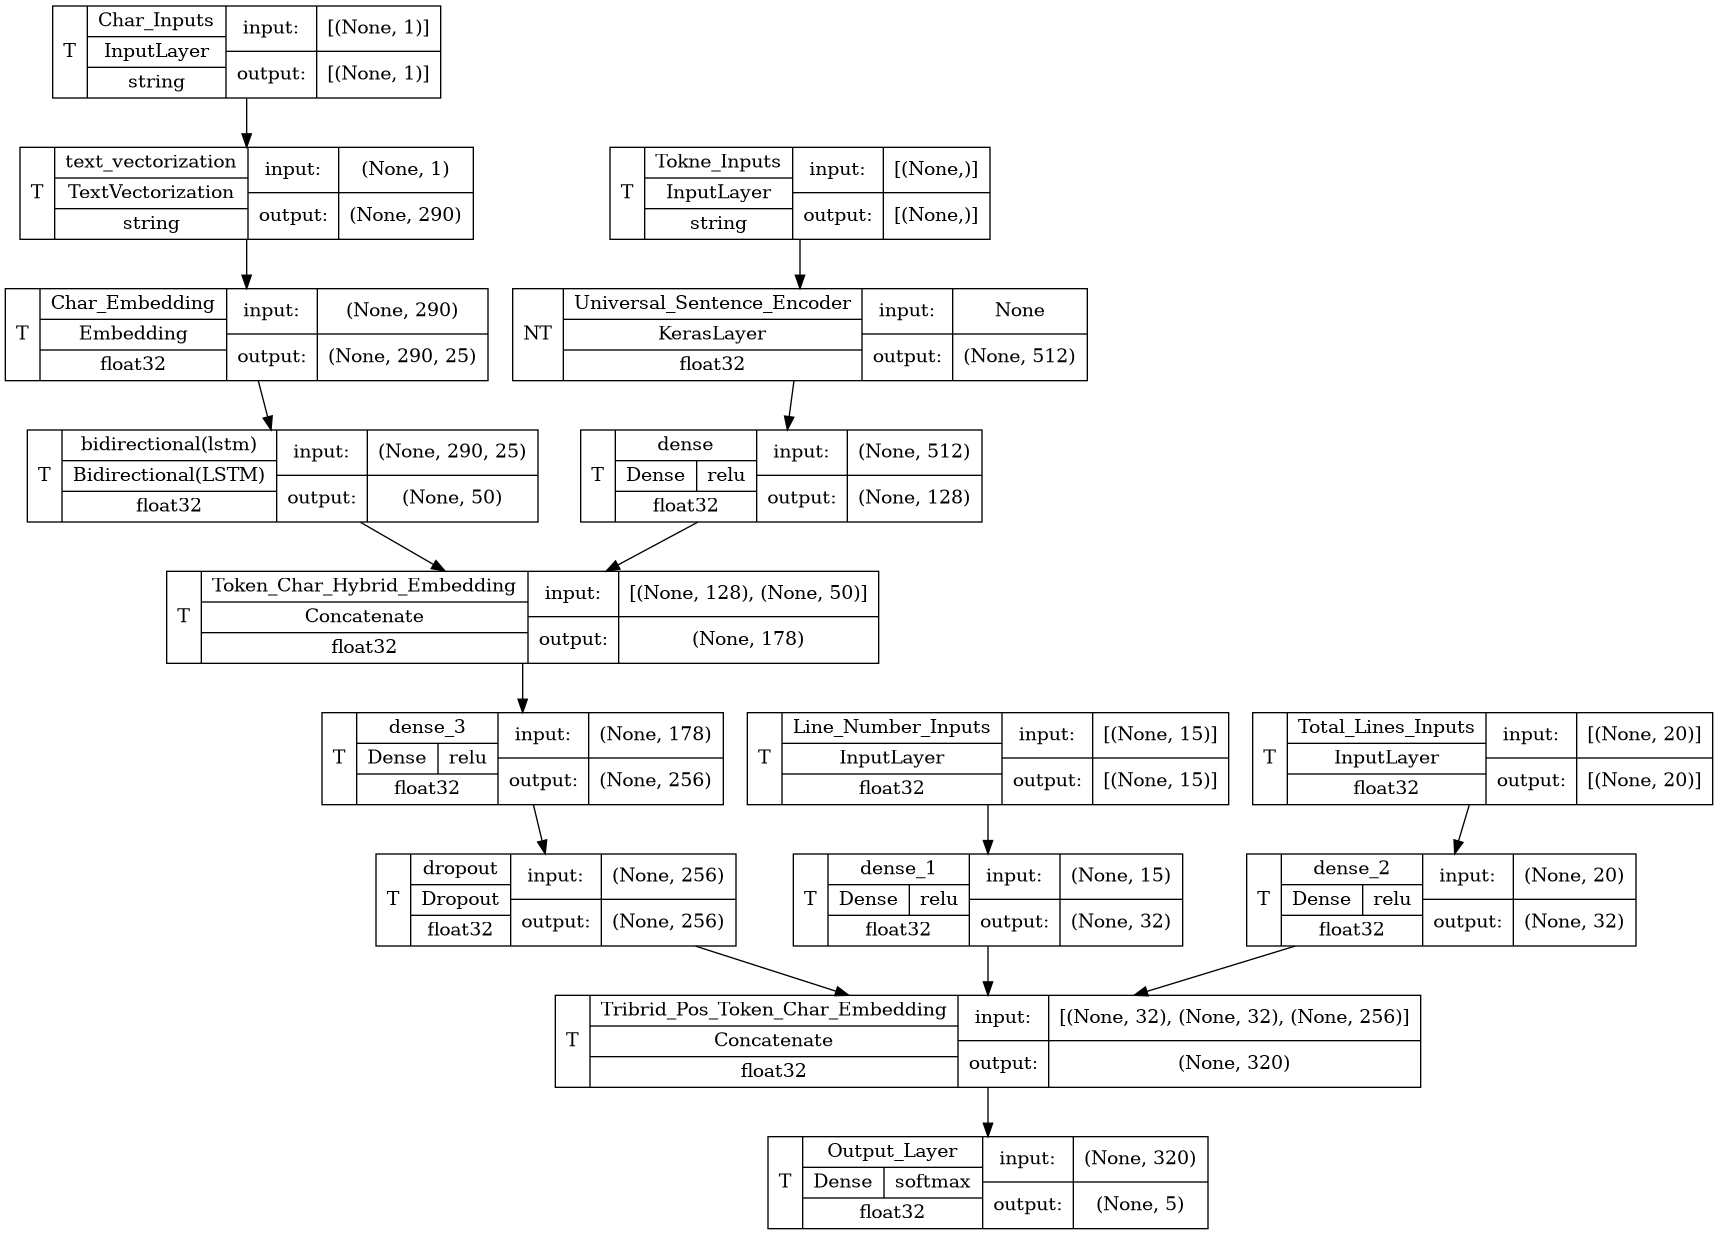

In [59]:
# Plotting The Model:
plot_model(model= model_pre_Token_char_pos_emb,
          show_shapes= True,
          show_dtype= True,
          show_layer_names= True,
          show_trainable= True,
          show_layer_activations= True)

In [60]:
# Compiling The Model:
model_pre_Token_char_pos_emb.compile(optimizer= Adam(),
                                    loss= CategoricalCrossentropy(),
                                    metrics= ['accuracy'])

In [62]:
# Fitting The Model:
history_model_pre_Token_char_pos_emb = model_pre_Token_char_pos_emb.fit(x= train_char_token_pos_dataset,
                                                                       validation_data= val_char_token_pos_dataset,
                                                                       epochs= 50,
                                                                       validation_steps= int(0.2 * len(val_char_token_pos_dataset)),
                                                                       callbacks = [early_stop])

Epoch 1/50


2026-02-23 12:58:25.069605: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-02-23 12:58:25.534382: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-02-23 12:58:26.728244: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f94e8003eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-23 12:58:26.728268: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-02-23 12:58:26.753458: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771851506.865356    3373 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proces

5627/5627 [==============================] - 238s 41ms/step - loss: 0.4696 - accuracy: 0.8215 - val_loss: 0.3716 - val_accuracy: 0.8540
Epoch 2/50
5627/5627 [==============================] - 246s 44ms/step - loss: 0.3689 - accuracy: 0.8615 - val_loss: 0.3531 - val_accuracy: 0.8581
Epoch 3/50
5627/5627 [==============================] - 251s 45ms/step - loss: 0.3427 - accuracy: 0.8717 - val_loss: 0.3472 - val_accuracy: 0.8657
Epoch 4/50
5627/5627 [==============================] - 254s 45ms/step - loss: 0.3249 - accuracy: 0.8785 - val_loss: 0.3488 - val_accuracy: 0.8659
Epoch 5/50
5627/5627 [==============================] - 256s 45ms/step - loss: 0.3108 - accuracy: 0.8834 - val_loss: 0.3489 - val_accuracy: 0.8652


# Evaluation of Model on Whole Validation Dataset and Predictions Using The Model:

In [64]:
model_pre_Token_char_pos_emb.evaluate(val_char_token_pos_dataset)

945/945 [==============================] - 23s 24ms/step - loss: 0.3560 - accuracy: 0.8663


[0.3559764623641968, 0.8662782907485962]

In [65]:
# Making Predictions Using The Model:
model_1_pred_probs = model_pre_Token_char_pos_emb.predict(val_char_token_pos_dataset)
model_1_pred_probs

945/945 [==============================] - 22s 23ms/step


array([[8.071e-01, 2.916e-04, 3.815e-06, 1.927e-01, 2.223e-05],
       [6.733e-01, 7.308e-05, 2.472e-04, 3.262e-01, 1.699e-05],
       [3.982e-01, 7.451e-06, 2.774e-02, 5.732e-01, 9.093e-04],
       ...,
       [6.199e-06, 3.082e-03, 1.116e-04, 1.192e-07, 9.966e-01],
       [4.244e-05, 8.584e-01, 1.210e-03, 1.729e-06, 1.404e-01],
       [3.832e-03, 9.902e-01, 2.352e-03, 1.318e-04, 3.281e-03]],
      dtype=float16)

In [66]:
# Converting Model Prediction Probabilities to Claas labels:
model_1_preds = tf.argmax(model_1_pred_probs, axis= 1)
model_1_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 1, 1])>

In [67]:
# Calculating Results for the Model:
model_1_results = calculate_results(y_true= val_labels_encoded,
                                    y_pred= model_1_preds)
model_1_results

{'accuracy': 86.62783000132399,
 'precision': 0.8673994007318252,
 'recall': 0.8662783000132398,
 'f1': 0.8638542871336881}

# Creating Model with Custom Embeddings for Tokens (Words)

In [70]:
# 1. Token Inputs:
token_inputs = Input(shape= [], dtype= tf.string, name= "Token_Inputs")
print(token_inputs.shape)
token_vectors = token_vectorizer(token_inputs)
print(token_vectors.shape)
token_embedding = token_embed(token_vectors)
print(token_embedding.shape)
x = GlobalMaxPool1D()(token_embedding)
token_outputs = Dense(128, activation= "relu")(x)
print(token_outputs.shape)
token_model = Model(token_inputs, token_outputs)

# 2. Character Inputs:
char_inputs = Input(shape= (1,), dtype= tf.string, name= "Char_Inputs")
print(char_inputs.shape)
char_vectors = char_vectorizer(char_inputs)
print(char_vectors.shape)
char_embeds = char_embed(char_vectors)
print(char_embeds.shape)
char_bi_lstm = Bidirectional(LSTM(25))(char_embeds)
print(char_bi_lstm.shape)
char_model = Model(char_inputs, char_bi_lstm)

# 3. Line Number Inputs:
line_number_inputs = Input(shape= (15,), dtype= tf.float32, name= "Line_Number_Inputs")
x = Dense(32, activation= "relu")(line_number_inputs)
line_number_model = Model(line_number_inputs, x)

# 4. Total Lines Inputs:
total_lines_inputs = Input(shape= (20,), dtype= tf.float32, name= "Total_Line_Inputs")
y = Dense(32, activation= "relu")(total_lines_inputs)
total_line_model = Model(total_lines_inputs, y)

# 5. Creating Hybrid Embedding using Token and Character Embeddings:
combined_embedding = Concatenate(name= "Token_Char_Hybrid_Embedding")([token_model.output,
                                                                       char_model.output])
z = Dense(256, activation= "relu")(combined_embedding)
z = Dropout(0.5)(z)

# 6. Combining Positional Embeddings with Combined Token and Char Embeddings into a Tribrid Embedding:
tribrid_embedding = Concatenate(name= "Tribrid_Pos_Token_Char_Embedding")([line_number_model.output,
                                                                           total_line_model.output,
                                                                           z])

# 7. Output Layer:
output_layer = Dense(5, activation= "softmax", name= "Output_Layer")(tribrid_embedding)

# 8. Creating The Model:
model_custom_Token_char_pos_emb = Model(inputs= [line_number_model.input,
                                             total_line_model.input,
                                             token_model.input,
                                             char_model.input],
                                    outputs = output_layer)

(None,)
(None, 55)
(None, 55, 128)
(None, 128)
(None, 1)
(None, 290)
(None, 290, 25)
(None, 50)


In [71]:
# Model Summary:
model_custom_Token_char_pos_emb.summary()

Model: "model_13"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 Token_Inputs (InputLayer)   [(None,)]                    0         []                            
                                                                                                  
 Token_Vectorizer (TextVect  (None, 55)                   0         ['Token_Inputs[0][0]']        
 orization)                                                                                       
                                                                                                  
 Char_Inputs (InputLayer)    [(None, 1)]                  0         []                            
                                                                                                  
 Token_Embedding (Embedding  (None, 55, 128)              8299648   ['Token_Vectorizer[1][0